University of Bristol, School of Economics Environmental Economics 2024/25
 (by Alvin Birdi and Christian Spielmann)


# **Renewable "Resources", the Gordon-Schaefer Model and Policy**

We first import some packages into python for calculations and visualisation. You will need to execute the code.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
%config InlineBackend.figure_format = 'retina'
from scipy.integrate import odeint
from scipy.optimize import fmin
%pip install sympy

from sympy import *


Note: you may need to restart the kernel to use updated packages.


## 1. Biological Regeneration

We follow the discussion of renewable resources in Hanley, Shogren and White (2013).

First, we describe how our species (i.e. fish) regenerates $\dot{x}=F(x)$. The appropriate regeneration function $F(x)$ depends on the biological regularities. Consider the following regeneration functions.


1.   Linear Regeneration
$\dot{x} = \gamma x$

2.   Logistic Regeneration
$\dot{x} = \gamma (1-{x \over k_{max}}) x$

3.   Depensation (Allee Effect)
$\dot{x} = \gamma (1-{x \over k_{max}}) x^\alpha$

4.   Critical Depensation
$\dot{x} = \gamma (\frac{x}{k_{min}}-1)(1-\frac{x}{k_{max}}) x$


In the following, we plot all these relationships. **You will need to execute the following code block.**

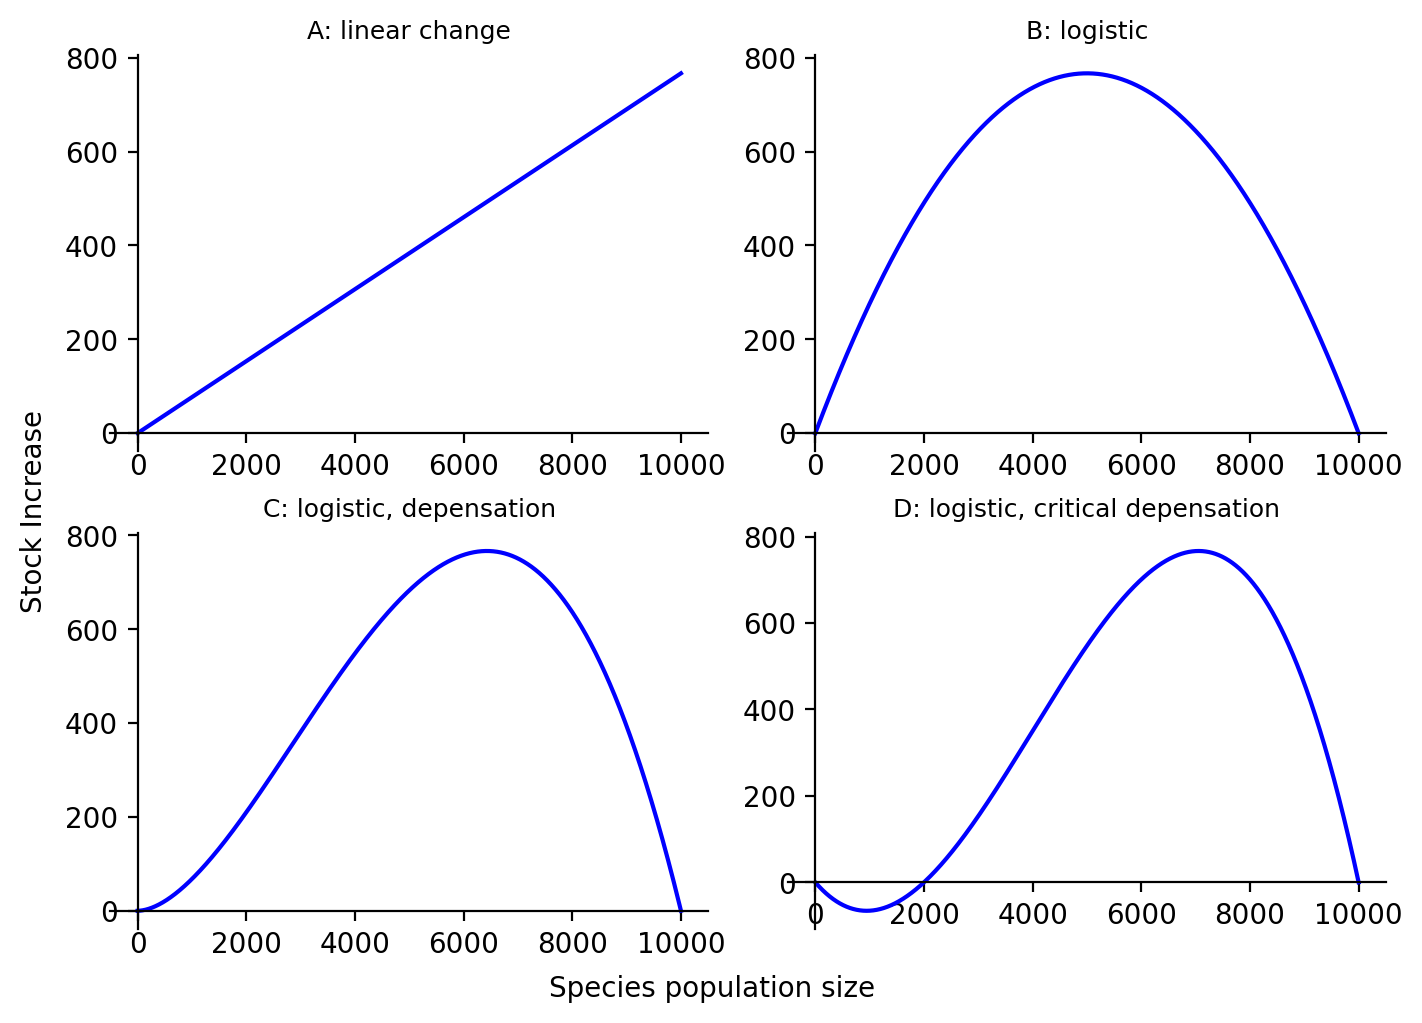

In [13]:
# plot the relationship between stock regeneration and the population size

gamma = 0.03
a = 1.8
k_min = 2000
k_max = 10000

x = np.linspace(0, 10000, num=15000)

xdot0 = gamma*x
xdot1 = gamma*(1-(x/k_max))*x
xdot2 = gamma*(1-x/k_max)*(x**a)
xdot3 = gamma*(1-x/k_max)*(x/k_min-1)*x

# Find max values for scaling
max_xdot0 = np.max(xdot0)
max_xdot1 = np.max(xdot1)
max_xdot2 = np.max(xdot2)
max_xdot3 = np.max(xdot3)

# Determine the target maximum regeneration rate
target_max = max(max_xdot0/100, max_xdot1/100, max_xdot2/100, max_xdot3/100)

# Scale functions to match the target maximum regeneration rate
xdot0 *= target_max / max_xdot0
xdot1 *= target_max / max_xdot1
xdot2 *= target_max / max_xdot2
xdot3 *= target_max / max_xdot3

# setting the axes at the centre
fig, ax = plt.subplots(2,2,sharey=False, constrained_layout=True, figsize=(7,5))

# Flatten the ax array for easier indexing
ax = ax.flatten()

# Adjusting the axes and adding plots
for i in range(4):
    ax[i].spines['left'].set_position('zero')
    ax[i].spines['bottom'].set_position('zero')
    ax[i].spines['right'].set_color('none')
    ax[i].spines['top'].set_color('none')
    ax[i].xaxis.set_ticks_position('bottom')
    ax[i].yaxis.set_ticks_position('left')


ax[0].plot(x, xdot0, 'b', label="k_min = 0")
ax[0].set_title("A: linear change", size=9)

ax[1].plot(x, xdot1, 'b')
ax[1].set_title("B: logistic", size=9)

ax[2].plot(x, xdot2, 'b')
ax[2].set_title("C: logistic, depensation", size=9)

ax[3].plot(x, xdot3, 'b')
ax[3].set_title("D: logistic, critical depensation", size=9)

fig.supxlabel("Species population size", size=10)
fig.supylabel("Stock Increase", size=10)

plt.show()

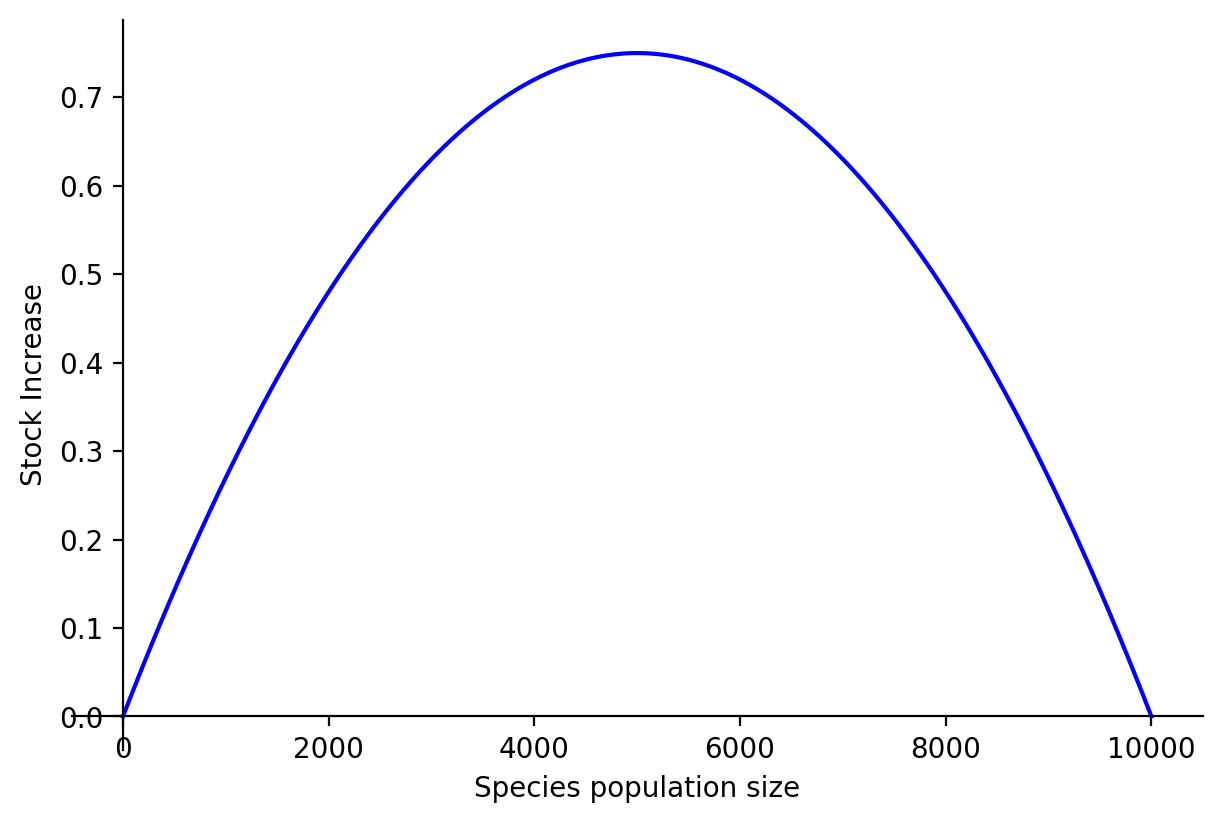

In [29]:
import numpy as np
import matplotlib.pyplot as plt

gamma = 0.03
k_max = 10000

x = np.linspace(0, 10000, num=15000)
xdot1 = gamma * (1 - (x / k_max)) * x

# Scale to match original target_max logic
target_max = np.max(xdot1) / 100
xdot1 *= target_max / np.max(xdot1)

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.plot(x, xdot1, 'b')
ax.set_xlabel("Species population size", size=10)
ax.set_ylabel("Stock Increase", size=10)

plt.show()



---

**Exercise 1:** Desribe the biological regeneration functions above intuitively. Can you think of any examples (not necessarily related to fish) which would be well described by these functions?

**Exercise 2:** Compare critical depensation and logistic reproduction. If left by itself, how would the species described by these two functions evolve over time? Sketch your answer! What are the differences?

---



We can plot the evolution of stocks (without harvesting) and check our answer from Exercise 2. **Execute the following code**

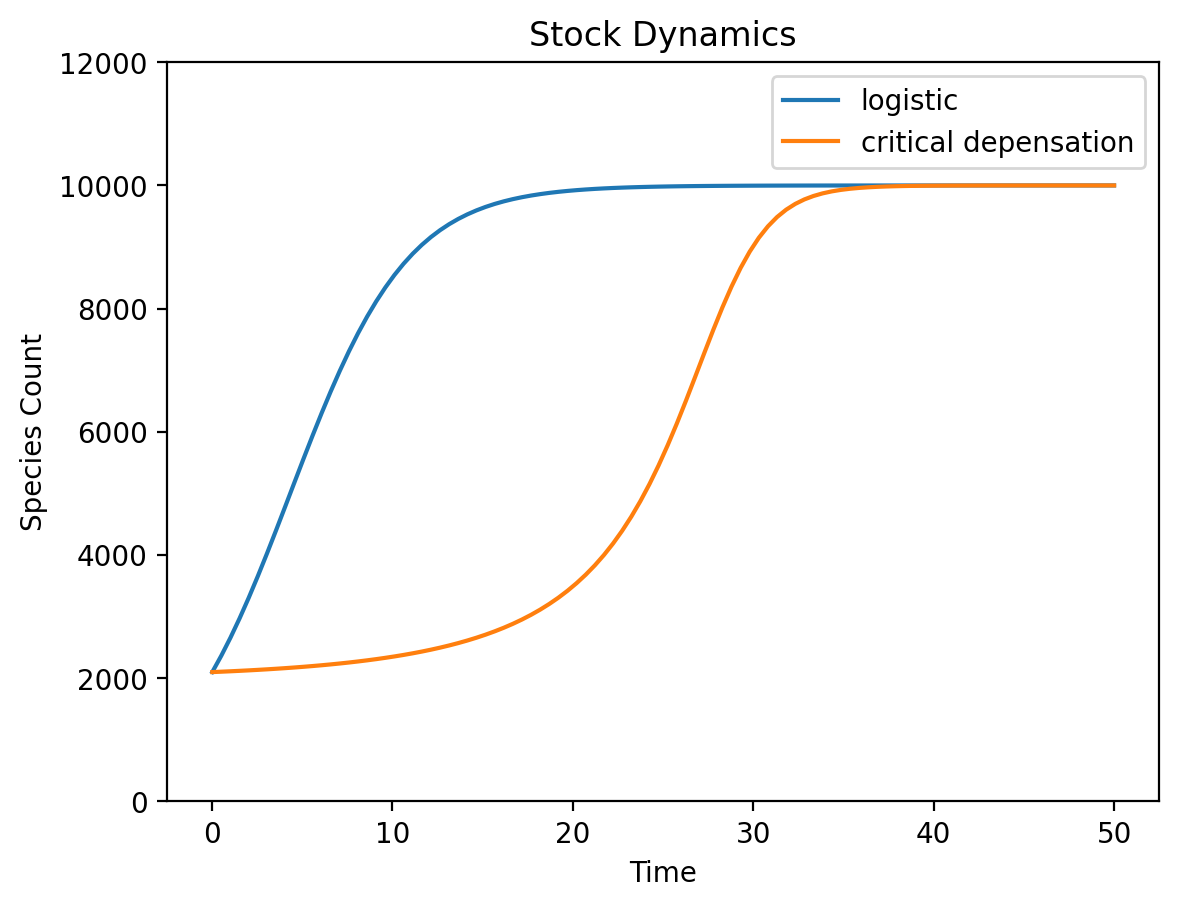

In [3]:
# Plot stock size over time using different regeneration functions

t = np.linspace(0.01, 50, num=100)

#a = 1.8
#x0 = 2100 # starting count of species
#gamma = 0.03 # regeneration rate
#k_min = 2000 # carrying capacity
#k_max = 10000 # carrying capacity


a = 1.8
x0 = 2100 # starting count of species
gamma = 0.03 # regeneration rate
k_min = 2000 # carrying capacity
k_max = 10000 # carrying capacity


def model1(x, t):

    dsdt = gamma*(1 - x/k_max)*x*target_max / max_xdot1

    return dsdt

def model2(x, t):

    dsdt = gamma*(x/k_min-1)*(1 - x/k_max)*x*target_max / max_xdot3

    return dsdt

# solve ordinary differential equation
y1 = odeint(model1, x0, t)
y2 = odeint(model2, x0, t)


# plot the simulation result
plt.plot(t, y1, label='logistic')
plt.plot(t, y2, label='critical depensation')
plt.xlabel("Time")
plt.ylabel("Species Count")
plt.title("Stock Dynamics")
plt.legend()
plt.ylim([0, 12000])
plt.show()


---

**Exercise 3**: Does your simulation confirm the answer you got in exercise 2?

**Exercise 4**: What environmental changes might result in a reduction in the parameter $\gamma$? What would this mean for regeneration. Do you think this is relevant in the real world? Try to simulate changes in $\gamma$ below. Explain.

---



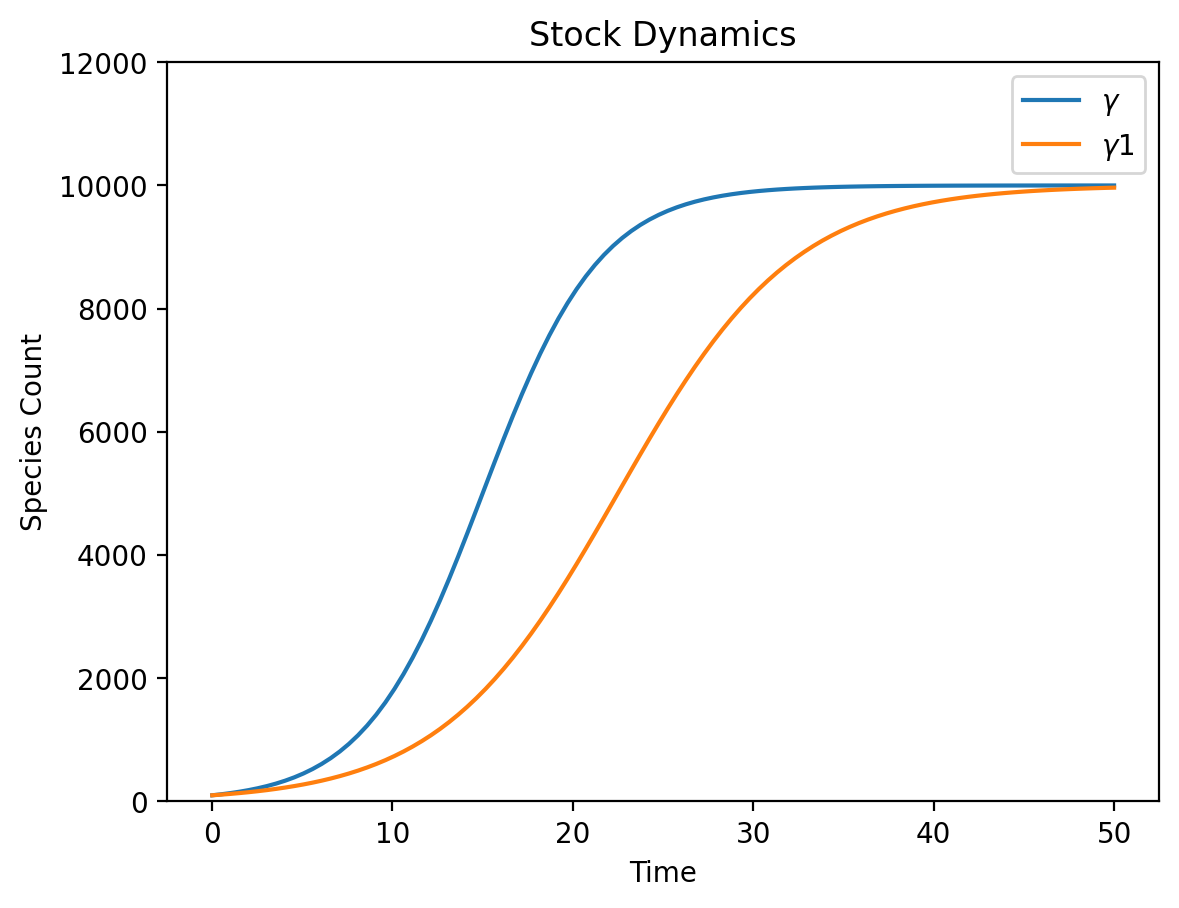

In [16]:
# Plot stock size over time using different regeneration functions

t = np.linspace(0.01, 50, num=100)

#a = 1.8
#x0 = 2100 # starting count of species
#gamma = 0.03 # regeneration rate
#k_min = 2000 # carrying capacity
#k_max = 10000 # carrying capacity


a = 1.8
x0 = 100 # starting count of species
gamma = 0.03 # regeneration rate
gamma1 = 0.02
k_min = 2000 # carrying capacity
k_max = 10000 # carrying capacity


def model1(x, t):

    dsdt = gamma*(1 - x/k_max)*x*target_max / max_xdot1

    return dsdt

def model2(x, t):

    dsdt = gamma1*(1 - x/k_max)*x*target_max / max_xdot1

    return dsdt

# solve ordinary differential equation
y1 = odeint(model1, x0, t)
y2 = odeint(model2, x0, t)


# plot the simulation result
plt.plot(t, y1, label='$\gamma$')
plt.plot(t, y2, label='$\gamma1$')
plt.xlabel("Time")
plt.ylabel("Species Count")
plt.title("Stock Dynamics")
plt.legend()
plt.ylim([0, 12000])
plt.show()

## 3. Gordon Schaefer Model with Harvesting

So far, the stock was left on its own, without any predator interaction (i.e. humans). We now introduce (human) harvesting into the model.

**You will need to execute the next block of code.**

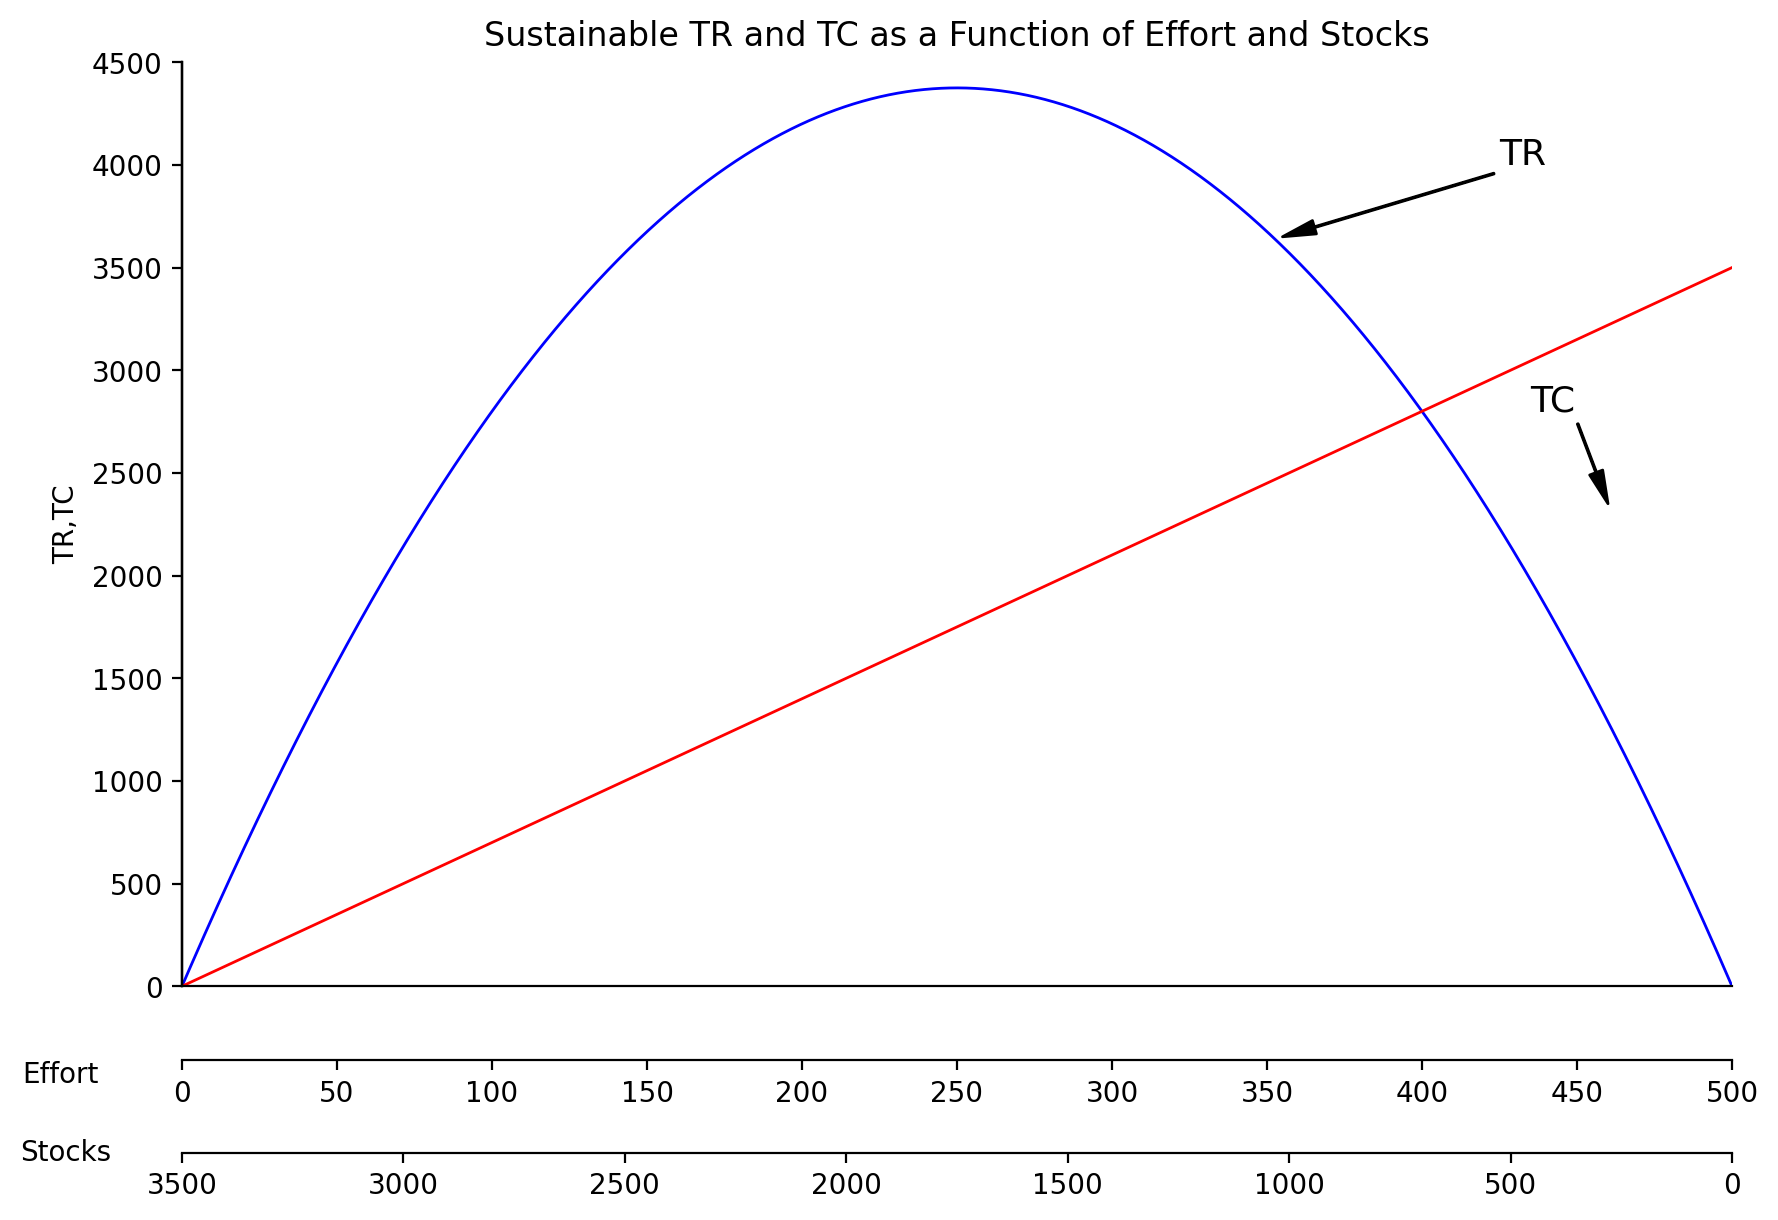

In [5]:
# Define model parameters
gamma=0.5 #potential reproduction rate
theta = .001 #catchability coefficient
Kmax = 3500 #carrying capacity
p = 10 # price of fish
c = 7 # cost of fishing
lw = 1 # line width for plotting

# generate all possible values of stocks in increments of 1
# Reshape into a column vector for calculations
x=np.arange(1,Kmax + 1).reshape((Kmax,1))

# find reproduction for each stock size
dxdt = gamma * x * ( 1- x / Kmax)  # Standard logistic growth model

#Calculate steady state effort needed to maintain each stock level
effort_ss = (gamma * x * (1 - x/Kmax))/(theta * x)

# Calculate total revenue (TR) and total cost (TC) at sustainable stock levels
# for each effort level, calculate
# 1. Sustainable TR = p h
# 2. TC

TR_ss = dxdt * p # # Total revenue = price per unit * sustainable harvest (dxdt)
TC = effort_ss * c # # Total cost = effort required * cost per unit effort

# Create a single plot
fix, ax1 = plt.subplots(1,1, figsize=(10,6))

# Plot total revenue (TR) and total cost (TC) as functions of effort
ax1.plot(effort_ss,TR_ss,lw=lw, c="b") # TR in blue
ax1.plot(effort_ss,TC,lw=lw,c='r') # TC in red

# Label the axes and add title
ax1.set_ylabel("TR,TC")
ax1.set_title("Sustainable TR and TC as a Function of Effort and Stocks")

# Add annotations to highlight TR and TC lines
ax1.annotate('TR', xy=(355, 3650), xytext=(425, 4000),
            arrowprops=dict(facecolor='black',width=.3,headwidth=5),fontsize=13)
ax1.annotate('TC', xy=(460, 2350), xytext=(435, 2800),
            arrowprops=dict(facecolor='black',width=.3,headwidth=5),fontsize=13)

# Adjust axis appearance
# Remove x-axis ticks from the main axis and place it at the zero level
ax1.spines['bottom'].set_position('zero')
ax1.set_xticks([]) # Remove default x-axis ticks
ax1.set_xticklabels([]) # Remove default x-axis tick labels


# Secondary X-axis: Adjust effort representation
ax2 = ax1.twiny() # Create a twin x-axis for effort
ax2.spines["bottom"].set_position(("axes", -0.08)) ## Offset the twin axis downward
ax2.xaxis.set_ticks_position("bottom")
ax2.xaxis.set_label_position("bottom")
ax2.set_xticks(range(0,550,50)) # Set tick marks for effort (from 0 to 500 in increments of 50)

# Third X-axis: Adjust stock representation
ax3=ax1.twiny() # Create a second twin x-axis for stock levels
## Offset the twin axis below the host
ax3.spines["bottom"].set_position(("axes", -0.18)) # Offset below the second x-axis
ax3.xaxis.set_ticks_position("bottom")
ax3.xaxis.set_label_position("bottom")
ax3.set_xticks(range(0,3600,500))# Set tick marks for stock (from 0 to 3500 in increments of 500)
ax3.set_xticklabels(reversed(range(0,3600,500))) # Reverse stock labels to align correctly

# Set limits for x and y axes
ax1.set_xlim(0,500) # Limit effort axis from 0 to 500
ax1.set_ylim(0,4500) # Limit revenue and cost axis from 0 to 4500

# Add labels for effort and stocks below the plot
plt.figtext(.045, .03, 'Effort') # Label for first x-axis (Effort)
plt.figtext(.044, -.035, 'Stocks') # Label for second x-axis (Stocks)

# Remove unnecessary spines (borders)
sbn.despine()

# Show the plot
plt.show()

---

**Exercise 5**: Explain what is meant by the open access outcome and the private profit maximising outcome. Show how large profits are in both cases

---

```
# This is formatted as code
```



In [7]:
# Calculate Open Access Equilibrium
soa = c/(p*theta)
print("Open Access Equilibrium Stock Size is: ", soa)
eoa = gamma*soa*(1-(soa/Kmax))/(theta*soa)
print("Open Access Equilibrium Effort is: ", round(eoa,1))
revs_oa = p*theta*soa*eoa
cost_oa = c*eoa
profits_oa = revs_oa - cost_oa
print("Open Access Profits is: ", round(profits_oa, 1))

# Calculate Profit Maximising Equilibrium
#Note: there is no maximize function so we will minimize negative profits (thereby maximizing profits)
negative_profits = lambda x : -1*((p*theta*x - c) * (gamma*x*(1-(x/Kmax)))/(theta*x))
x_initial_guess = 3000
x_star = fmin(negative_profits, x_initial_guess)
print("Profit Maximizing Steady State Stocks (x*): ", x_star[0].round(2))
h_star = gamma*x_star*(1-(x_star/Kmax))/(theta*x_star)
print("Profit Maximizing Effort (h*) is", h_star[0].round(2))
revs_star = p*theta*x_star*h_star
print("Total Revenues at h* is", revs_star[0].round(2))
cost_star = c*h_star
print("Total Costs at h* is",cost_star[0].round(2))
profits_star = revs_star - cost_star
print("Profits at h* is ", profits_star[0].round(2))

Open Access Equilibrium Stock Size is:  700.0
Open Access Equilibrium Effort is:  400.0
Open Access Profits is:  0.0
Optimization terminated successfully.
         Current function value: -2800.000000
         Iterations: 26
         Function evaluations: 52
Profit Maximizing Steady State Stocks (x*):  2100.0
Profit Maximizing Effort (h*) is 200.0
Total Revenues at h* is 4200.0
Total Costs at h* is 1400.0
Profits at h* is  2800.0


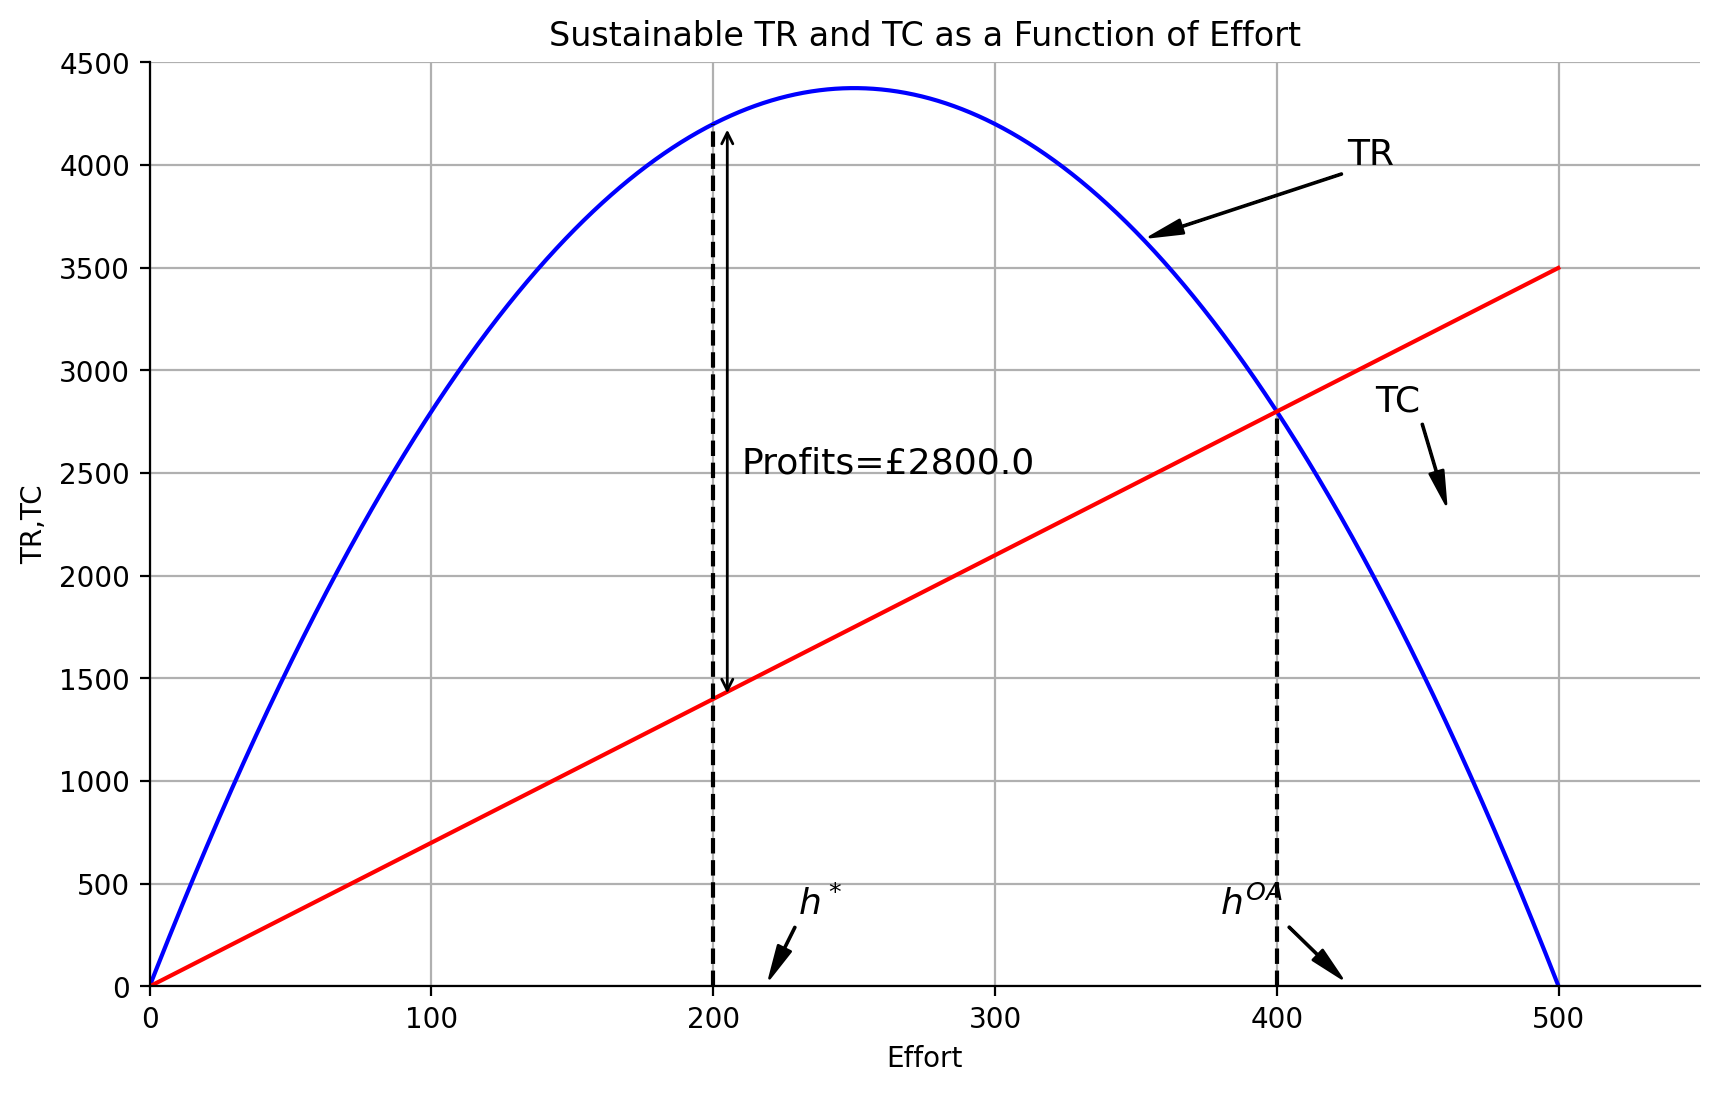

In [ ]:
    plt.figure(figsize=(10, 6))
    plt.subplot(111)
    plt.plot(effort_ss,TR_ss,c="b")
    plt.plot(effort_ss,TC,c='r')
    plt.xlabel("Effort")
    plt.ylabel("TR,TC")
    plt.title("Sustainable TR and TC as a Function of Effort")
    plt.annotate('TR', xy=(355, 3650), xytext=(425, 4000),
                arrowprops=dict(facecolor='black',width=.3,headwidth=5),fontsize=13)
    plt.annotate('TC', xy=(460, 2350), xytext=(435, 2800),
                arrowprops=dict(facecolor='black',width=.3,headwidth=5),fontsize=13)

    plt.annotate('$h^*$', xy=(220, 40), xytext=(230, 350),
                arrowprops=dict(facecolor='black',width=.3,headwidth=5),fontsize=13)

    plt.annotate('$h^{OA}$', xy=(423, 40), xytext=(380, 350),
                arrowprops=dict(facecolor='black',width=.3,headwidth=5),fontsize=13)

    plt.plot((h_star[0], h_star[0]), (0, revs_star[0]), 'k--')
    plt.plot((eoa, eoa), (0, c*eoa), 'k--')
    plt.annotate(
        '', xy=(h_star+5, revs_star), xycoords='data',
        xytext=(h_star+5, cost_star), textcoords='data',
        arrowprops={'arrowstyle': '<->'})
    plt.annotate(
        'Profits=£%s'%(str(np.around(profits_star[0],2))), xy=(h_star+5, 2500), xycoords='data',
        xytext=(5, 0), textcoords='offset points',fontsize=13)
    plt.xlim(0,550)
    plt.ylim(0,4500)
    sbn.despine()
    plt.grid()

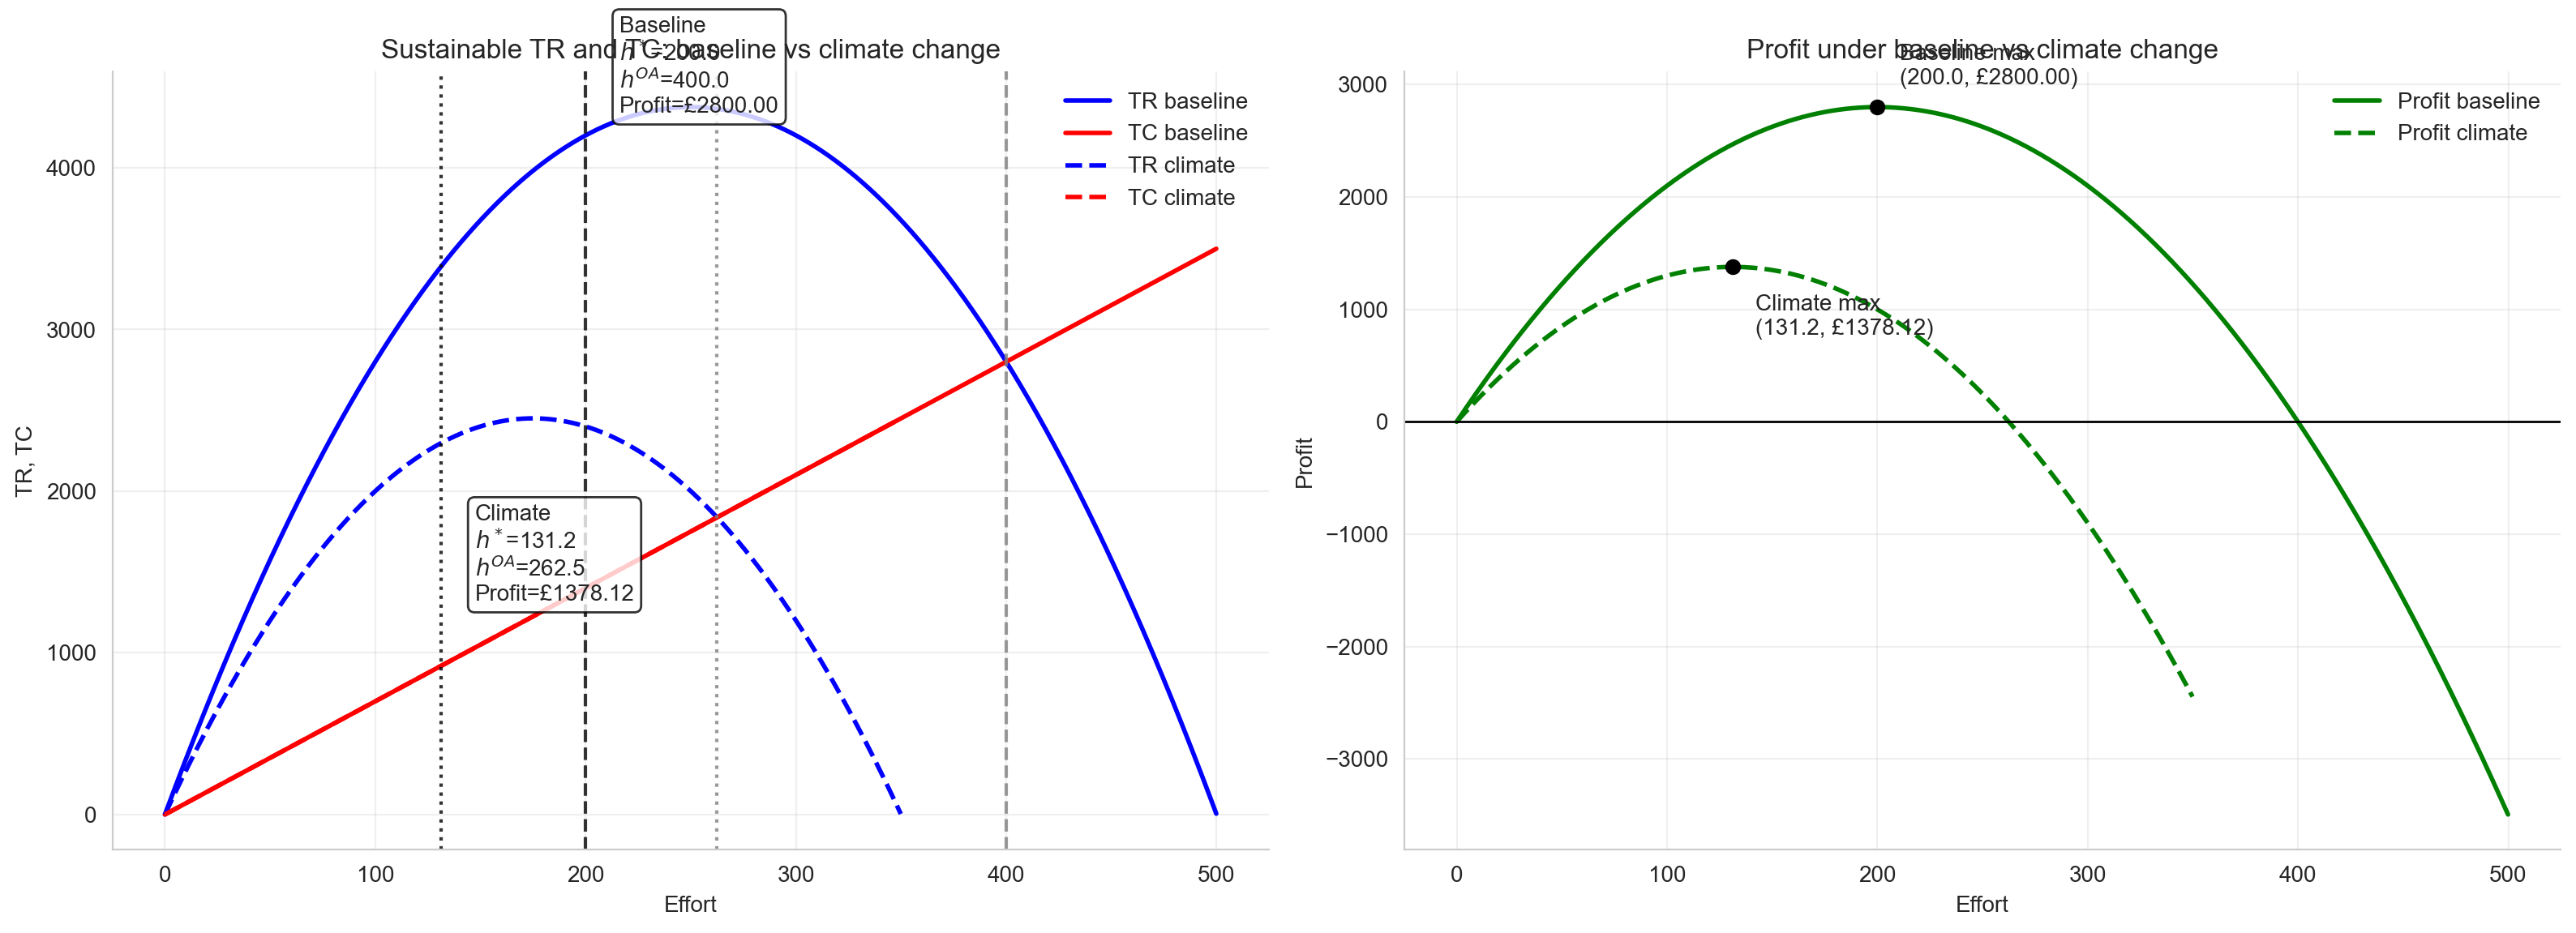

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

# --------------------------
# Parameters
# --------------------------
theta = 0.001
p = 10
c = 7
lw = 2

# Baseline
gamma_base = 0.5
K_base = 3500

# Climate-change scenario
# Example: lower reproduction and lower carrying capacity
gamma_cc = 0.35
K_cc = 2800

def fishery_scenario(gamma, Kmax, theta, p, c):
    x = np.arange(1, Kmax + 1).reshape(-1, 1)

    dxdt = gamma * x * (1 - x / Kmax)
    effort_ss = (gamma * x * (1 - x / Kmax)) / (theta * x)

    TR_ss = (dxdt * p).ravel()
    TC = (effort_ss * c).ravel()
    profits = TR_ss - TC
    effort_ss = effort_ss.ravel()

    # Sort by effort so plotting and indexing are clean
    order = np.argsort(effort_ss)
    effort_ss = effort_ss[order]
    TR_ss = TR_ss[order]
    TC = TC[order]
    profits = profits[order]

    # Profit-maximising point
    i_star = np.argmax(profits)
    h_star = effort_ss[i_star]
    revs_star = TR_ss[i_star]
    cost_star = TC[i_star]
    profits_star = profits[i_star]

    # Open-access point: last effort where profits are non-negative
    nonneg = np.where(profits >= 0)[0]
    eoa = effort_ss[nonneg[-1]] if len(nonneg) > 0 else np.nan

    return {
        "gamma": gamma,
        "Kmax": Kmax,
        "x": x,
        "effort_ss": effort_ss,
        "TR_ss": TR_ss,
        "TC": TC,
        "profits": profits,
        "h_star": h_star,
        "revs_star": revs_star,
        "cost_star": cost_star,
        "profits_star": profits_star,
        "eoa": eoa
    }

base = fishery_scenario(gamma_base, K_base, theta, p, c)
cc = fishery_scenario(gamma_cc, K_cc, theta, p, c)

# --------------------------
# Plot
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Panel 1: TR and TC ----
ax = axes[0]

# Baseline
ax.plot(base["effort_ss"], base["TR_ss"], c="b", lw=lw, label="TR baseline")
ax.plot(base["effort_ss"], base["TC"], c="r", lw=lw, label="TC baseline")

# Climate scenario
ax.plot(cc["effort_ss"], cc["TR_ss"], c="b", lw=lw, ls="--", label="TR climate")
ax.plot(cc["effort_ss"], cc["TC"], c="r", lw=lw, ls="--", label="TC climate")

# Baseline markers
ax.axvline(base["h_star"], color="black", ls="--", alpha=0.8)
ax.axvline(base["eoa"], color="grey", ls="--", alpha=0.8)
ax.annotate(
    f"Baseline\n$h^*$={base['h_star']:.1f}\n$h^{{OA}}$={base['eoa']:.1f}\nProfit=£{base['profits_star']:.2f}",
    xy=(base["h_star"], base["revs_star"]),
    xytext=(15, 10),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
)

# Climate markers
ax.axvline(cc["h_star"], color="black", ls=":", alpha=0.8)
ax.axvline(cc["eoa"], color="grey", ls=":", alpha=0.8)
ax.annotate(
    f"Climate\n$h^*$={cc['h_star']:.1f}\n$h^{{OA}}$={cc['eoa']:.1f}\nProfit=£{cc['profits_star']:.2f}",
    xy=(cc["h_star"], cc["revs_star"]),
    xytext=(15, -70),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
)

ax.set_xlabel("Effort")
ax.set_ylabel("TR, TC")
ax.set_title("Sustainable TR and TC: baseline vs climate change")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

# ---- Panel 2: Profit curve ----
ax = axes[1]
ax.plot(base["effort_ss"], base["profits"], c="green", lw=lw, label="Profit baseline")
ax.plot(cc["effort_ss"], cc["profits"], c="green", lw=lw, ls="--", label="Profit climate")
ax.axhline(0, color="black", lw=1)

ax.scatter(base["h_star"], base["profits_star"], color="black", zorder=5)
ax.scatter(cc["h_star"], cc["profits_star"], color="black", zorder=5)

ax.annotate(
    f"Baseline max\n({base['h_star']:.1f}, £{base['profits_star']:.2f})",
    xy=(base["h_star"], base["profits_star"]),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=10
)

ax.annotate(
    f"Climate max\n({cc['h_star']:.1f}, £{cc['profits_star']:.2f})",
    xy=(cc["h_star"], cc["profits_star"]),
    xytext=(10, -30),
    textcoords="offset points",
    fontsize=10
)

ax.set_xlabel("Effort")
ax.set_ylabel("Profit")
ax.set_title("Profit under baseline vs climate change")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

sbn.despine()
plt.tight_layout()
plt.show()

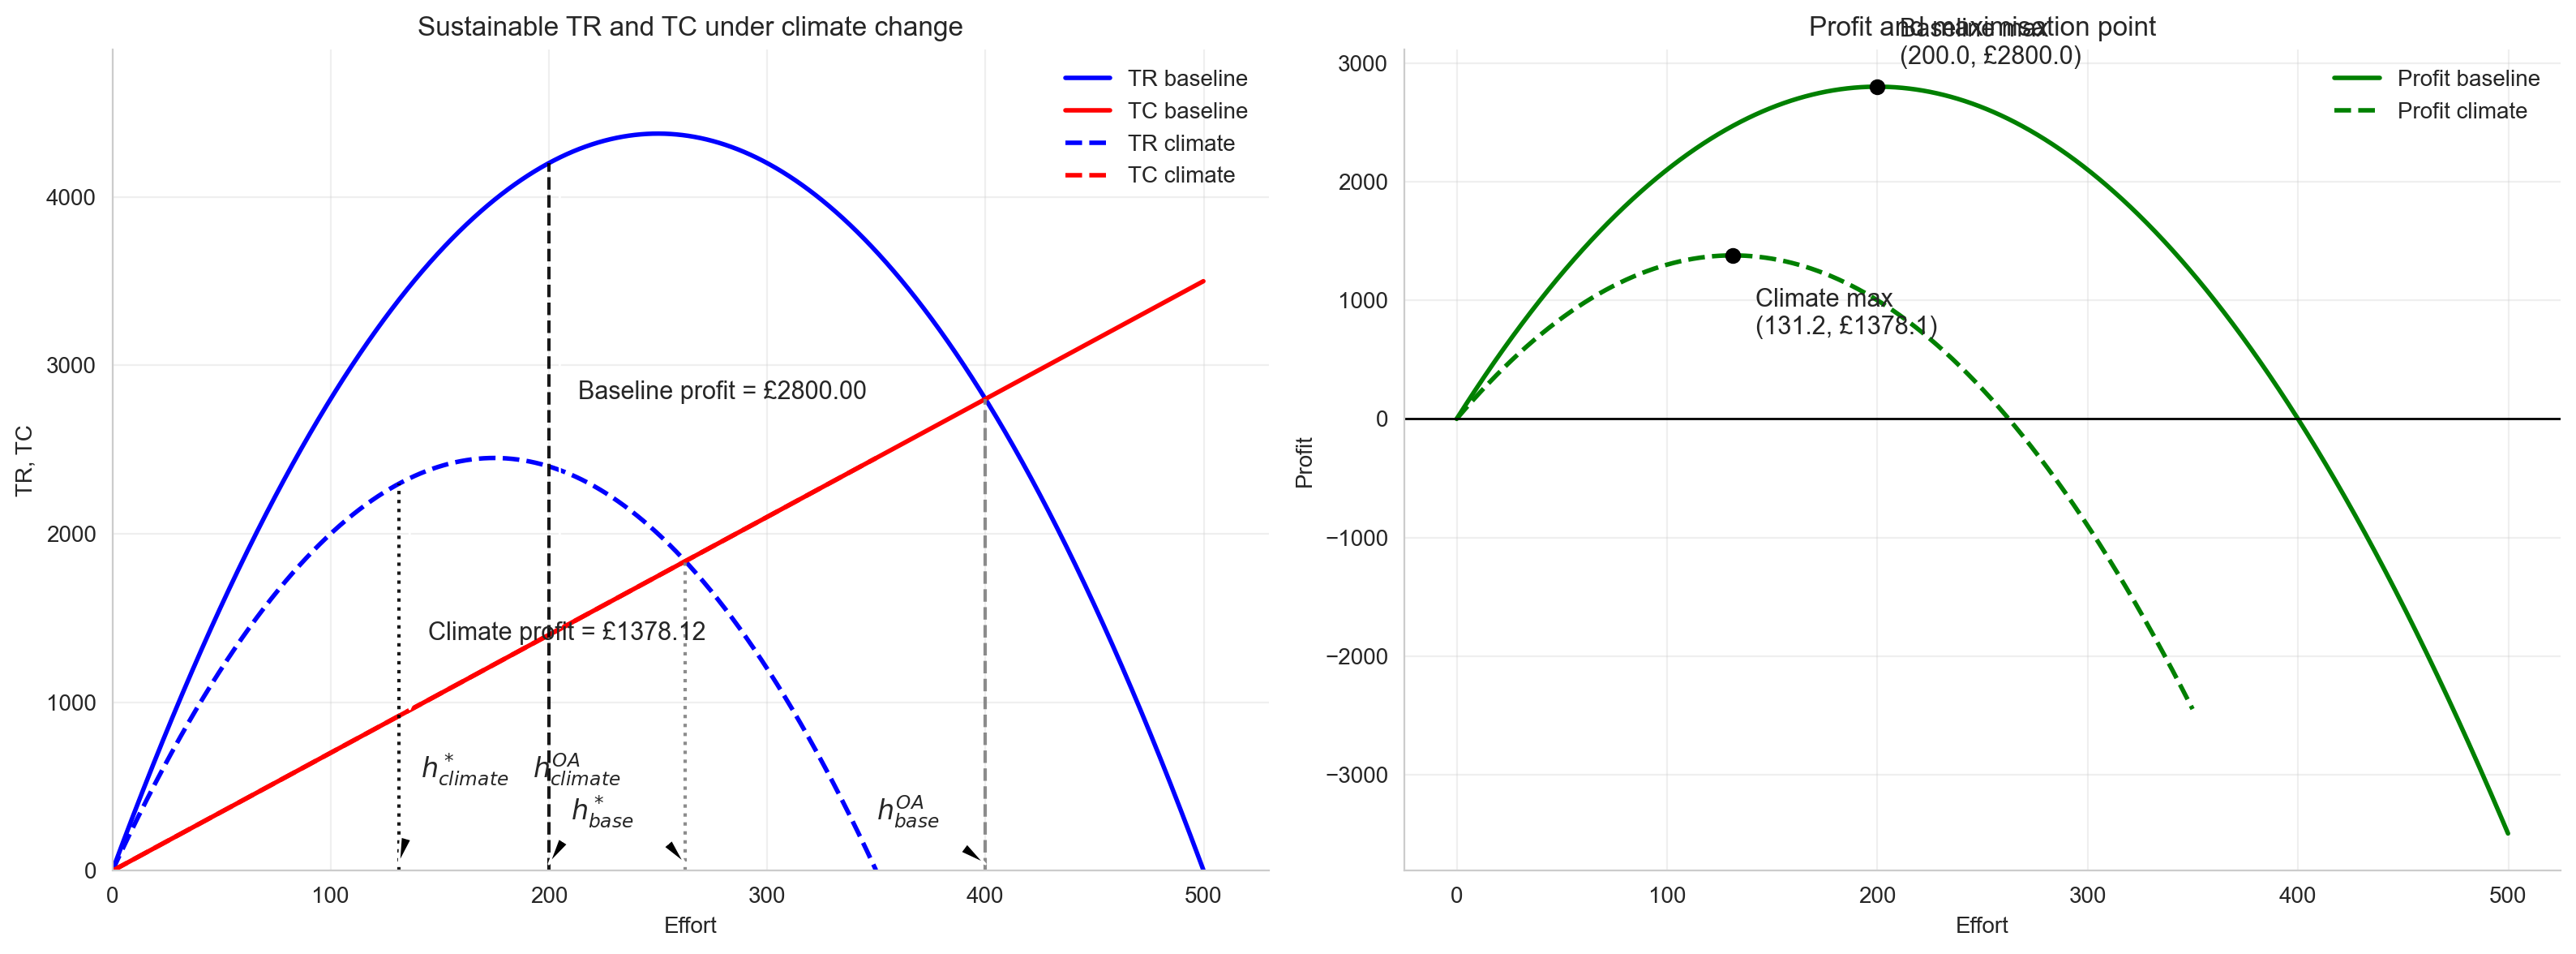

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
from scipy.optimize import fmin

# ----------------------------
# Common parameters
# ----------------------------
theta = 0.001
p = 10
c = 7
lw = 2

# ----------------------------
# Scenarios
# ----------------------------
# Baseline
gamma_base = 0.5
Kmax_base = 3500

# Climate change scenario
# Example: lower reproduction and lower carrying capacity
gamma_cc = 0.35
Kmax_cc = 2800

def solve_fishery(gamma, Kmax, theta, p, c):
    # Stocks
    x = np.arange(1, Kmax + 1).reshape((Kmax, 1))

    # Biological growth
    dxdt = gamma * x * (1 - x / Kmax)

    # Sustainable effort
    effort_ss = (gamma * x * (1 - x / Kmax)) / (theta * x)

    # Revenue, cost, profit
    TR_ss = dxdt * p
    TC = effort_ss * c
    profits = TR_ss - TC

    # Open access equilibrium
    soa = c / (p * theta)
    eoa = gamma * soa * (1 - (soa / Kmax)) / (theta * soa)
    revs_oa = p * theta * soa * eoa
    cost_oa = c * eoa
    profits_oa = revs_oa - cost_oa

    # Profit-maximising equilibrium
    negative_profits = lambda xval: -1 * (
        (p * theta * xval - c) * (gamma * xval * (1 - (xval / Kmax))) / (theta * xval)
    )

    x_initial_guess = min(3000, Kmax - 1)
    x_star = fmin(negative_profits, x_initial_guess, disp=False)

    h_star = gamma * x_star * (1 - (x_star / Kmax)) / (theta * x_star)
    revs_star = p * theta * x_star * h_star
    cost_star = c * h_star
    profits_star = revs_star - cost_star

    # Flatten for plotting
    effort_ss = effort_ss.flatten()
    TR_ss = TR_ss.flatten()
    TC = TC.flatten()
    profits = profits.flatten()

    # Sort by effort so lines plot properly
    order = np.argsort(effort_ss)
    effort_ss = effort_ss[order]
    TR_ss = TR_ss[order]
    TC = TC[order]
    profits = profits[order]

    return {
        "gamma": gamma,
        "Kmax": Kmax,
        "x": x,
        "dxdt": dxdt,
        "effort_ss": effort_ss,
        "TR_ss": TR_ss,
        "TC": TC,
        "profits": profits,
        "soa": soa,
        "eoa": eoa,
        "revs_oa": revs_oa,
        "cost_oa": cost_oa,
        "profits_oa": profits_oa,
        "x_star": x_star[0],
        "h_star": h_star[0],
        "revs_star": revs_star[0],
        "cost_star": cost_star[0],
        "profits_star": profits_star[0]
    }

# Solve both scenarios
base = solve_fishery(gamma_base, Kmax_base, theta, p, c)
cc = solve_fishery(gamma_cc, Kmax_cc, theta, p, c)

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===== Panel 1: TR and TC =====
ax = axes[0]

# Baseline
ax.plot(base["effort_ss"], base["TR_ss"], c="b", lw=lw, label="TR baseline")
ax.plot(base["effort_ss"], base["TC"], c="r", lw=lw, label="TC baseline")

# Climate change
ax.plot(cc["effort_ss"], cc["TR_ss"], c="b", lw=lw, ls="--", label="TR climate")
ax.plot(cc["effort_ss"], cc["TC"], c="r", lw=lw, ls="--", label="TC climate")

# Baseline equilibrium markers
ax.plot((base["h_star"], base["h_star"]), (0, base["revs_star"]), 'k--', alpha=0.9)
ax.plot((base["eoa"], base["eoa"]), (0, c * base["eoa"]), 'grey', ls='--', alpha=0.9)

ax.annotate(
    '', xy=(base["h_star"] + 5, base["revs_star"]),
    xytext=(base["h_star"] + 5, base["cost_star"]),
    arrowprops={'arrowstyle': '<->'}
)
ax.annotate(
    f'Baseline profit = £{base["profits_star"]:.2f}',
    xy=(base["h_star"] + 5, (base["revs_star"] + base["cost_star"]) / 2),
    xytext=(8, 0),
    textcoords='offset points',
    fontsize=11
)

ax.annotate(r'$h^*_{base}$', xy=(base["h_star"], 40), xytext=(base["h_star"] + 10, 300),
            arrowprops=dict(facecolor='black', width=.3, headwidth=5), fontsize=12)

ax.annotate(r'$h^{OA}_{base}$', xy=(base["eoa"], 40), xytext=(base["eoa"] - 50, 300),
            arrowprops=dict(facecolor='black', width=.3, headwidth=5), fontsize=12)

# Climate equilibrium markers
ax.plot((cc["h_star"], cc["h_star"]), (0, cc["revs_star"]), 'k:', alpha=0.9)
ax.plot((cc["eoa"], cc["eoa"]), (0, c * cc["eoa"]), color='grey', ls=':', alpha=0.9)

ax.annotate(
    '', xy=(cc["h_star"] + 5, cc["revs_star"]),
    xytext=(cc["h_star"] + 5, cc["cost_star"]),
    arrowprops={'arrowstyle': '<->'}
)
ax.annotate(
    f'Climate profit = £{cc["profits_star"]:.2f}',
    xy=(cc["h_star"] + 5, (cc["revs_star"] + cc["cost_star"]) / 2),
    xytext=(8, -18),
    textcoords='offset points',
    fontsize=11
)

ax.annotate(r'$h^*_{climate}$', xy=(cc["h_star"], 40), xytext=(cc["h_star"] + 10, 550),
            arrowprops=dict(facecolor='black', width=.3, headwidth=5), fontsize=12)

ax.annotate(r'$h^{OA}_{climate}$', xy=(cc["eoa"], 40), xytext=(cc["eoa"] - 70, 550),
            arrowprops=dict(facecolor='black', width=.3, headwidth=5), fontsize=12)

ax.set_xlabel("Effort")
ax.set_ylabel("TR, TC")
ax.set_title("Sustainable TR and TC under climate change")
ax.set_xlim(0, max(base["effort_ss"].max(), cc["effort_ss"].max()) + 30)
ax.set_ylim(0, max(base["TR_ss"].max(), cc["TR_ss"].max()) + 500)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False)

# ===== Panel 2: Profit =====
ax2 = axes[1]

ax2.plot(base["effort_ss"], base["profits"], c="green", lw=lw, label="Profit baseline")
ax2.plot(cc["effort_ss"], cc["profits"], c="green", lw=lw, ls="--", label="Profit climate")

ax2.axhline(0, color='black', lw=1)
ax2.scatter(base["h_star"], base["profits_star"], color='black', zorder=5)
ax2.scatter(cc["h_star"], cc["profits_star"], color='black', zorder=5)

ax2.annotate(
    f'Baseline max\n({base["h_star"]:.1f}, £{base["profits_star"]:.1f})',
    xy=(base["h_star"], base["profits_star"]),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=11
)

ax2.annotate(
    f'Climate max\n({cc["h_star"]:.1f}, £{cc["profits_star"]:.1f})',
    xy=(cc["h_star"], cc["profits_star"]),
    xytext=(10, -35),
    textcoords='offset points',
    fontsize=11
)

ax2.set_xlabel("Effort")
ax2.set_ylabel("Profit")
ax2.set_title("Profit and maximisation point")
ax2.grid(True, alpha=0.3)
ax2.legend(frameon=False)

sbn.despine()
plt.tight_layout()
plt.show()

---

**Exercise 6:** From a conservation perspective, discuss which equilibrium you may prefer, $h^{OA}$ or $h^*$. Why?

**Exercise 7:** Imagine fishing technology advances. Find a real world example. How would you model this in the simulation? How does it impact the outcome of the model.

---


In [9]:
theta=0.001 #Set initial theta
xi=1.0 # Set tech improvement parameter
print("Old theta is", theta)
theta = theta * xi
print("New theta is", theta)

Old theta is 0.001
New theta is 0.001


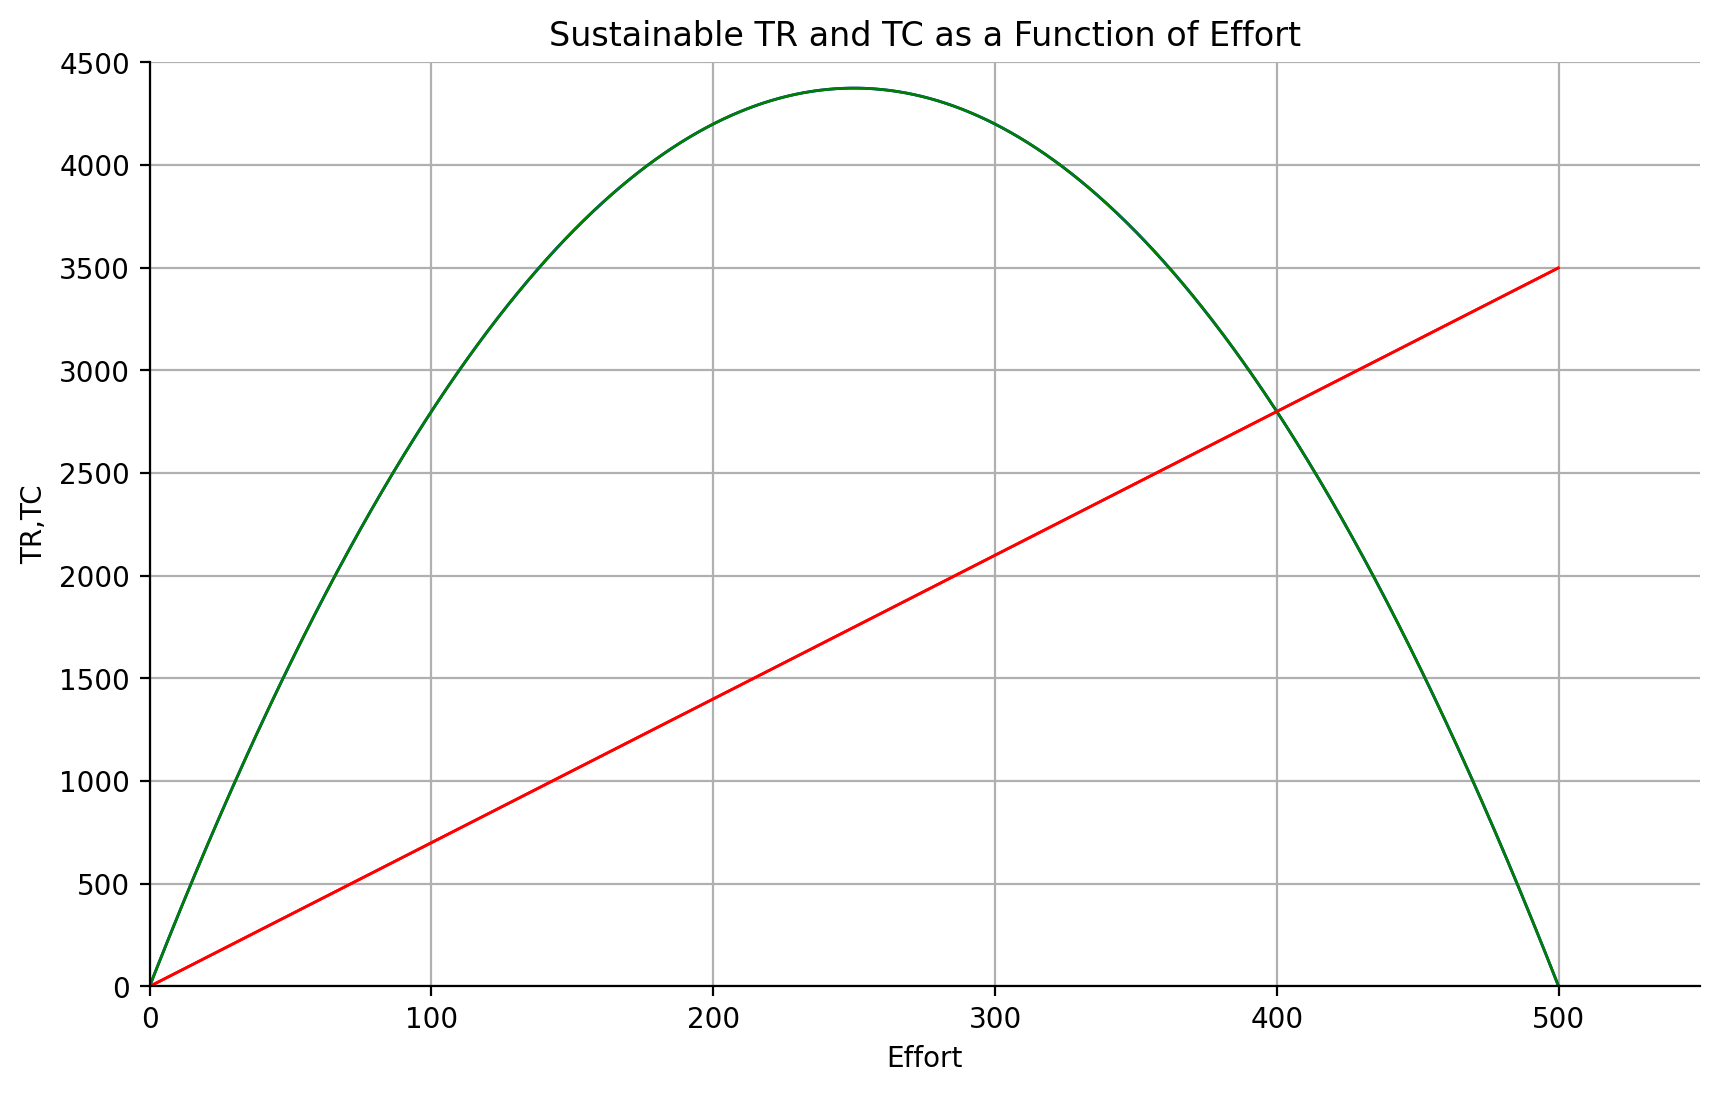

In [10]:
# for each stock size, store steady state effort
effort_ss_tech = (gamma * x * (1 - x/Kmax))/(theta*x)

TR_ss_tech = dxdt * p
TC_tech = effort_ss_tech * c

plt.figure(figsize=(10, 6))
plt.subplot(111)
lw = 1
plt.plot(effort_ss,TR_ss,lw=lw, c="b")
plt.plot(effort_ss,TC,lw=lw,c='r')

plt.plot(effort_ss_tech,TR_ss_tech,lw=lw, c="g")
plt.plot(effort_ss_tech,TC_tech,lw=lw,c='r')

plt.xlabel("Effort")
plt.ylabel("TR,TC")
plt.title("Sustainable TR and TC as a Function of Effort")
#plt.annotate('TRold', xy=(355, 3650), xytext=(400, 4000),
            #arrowprops=dict(facecolor='black',width=.3,headwidth=5),fontsize=13)

#plt.annotate('TRnew', xy=(275, 2750), xytext=(325, 3200),
            #arrowprops=dict(facecolor='black',width=.3,headwidth=5),fontsize=13)

#plt.annotate('TC', xy=(460, 2350), xytext=(435, 2800),
            #arrowprops=dict(facecolor='black',width=.3,headwidth=5),fontsize=13)
plt.xlim(0,550)
plt.ylim(0,4500)
sbn.despine()
plt.grid()

## 4. Endangered Animals

---

**Question 8:** You are asked to analyse hunting of endangered elephants and rhinos.

1.   Use GenAI to understand what the CITES ban is and how it impacts elephants and rhinos. Try to find out what the Appendices contain and also how and why certain Southern African countries file "exemptions" to CITES.

2.   Use the standard Gordon-Schaefer model with an extinction level of effort (an effort level which leads to such low stocks that the species cannot survive). This is shown in the simulation below (**you will need to execute the next block**).

 We are particularly interested in ivory trades so the y axis here is the trade in animal products rather than the animals themselves (as with the fish model).We assume there are no restrictions on hunting. Answer the following questions

a.   Is the open access outcome sustainable?

b.   What may happen to technologies or prices which would change your answer? Why might these changes happen?

c.   How could we analyse the impact of the CITES ban within the model?

d.   How could hunting licencing help to deal with it? Discuss this policy.

---

Text(450, 0, '')

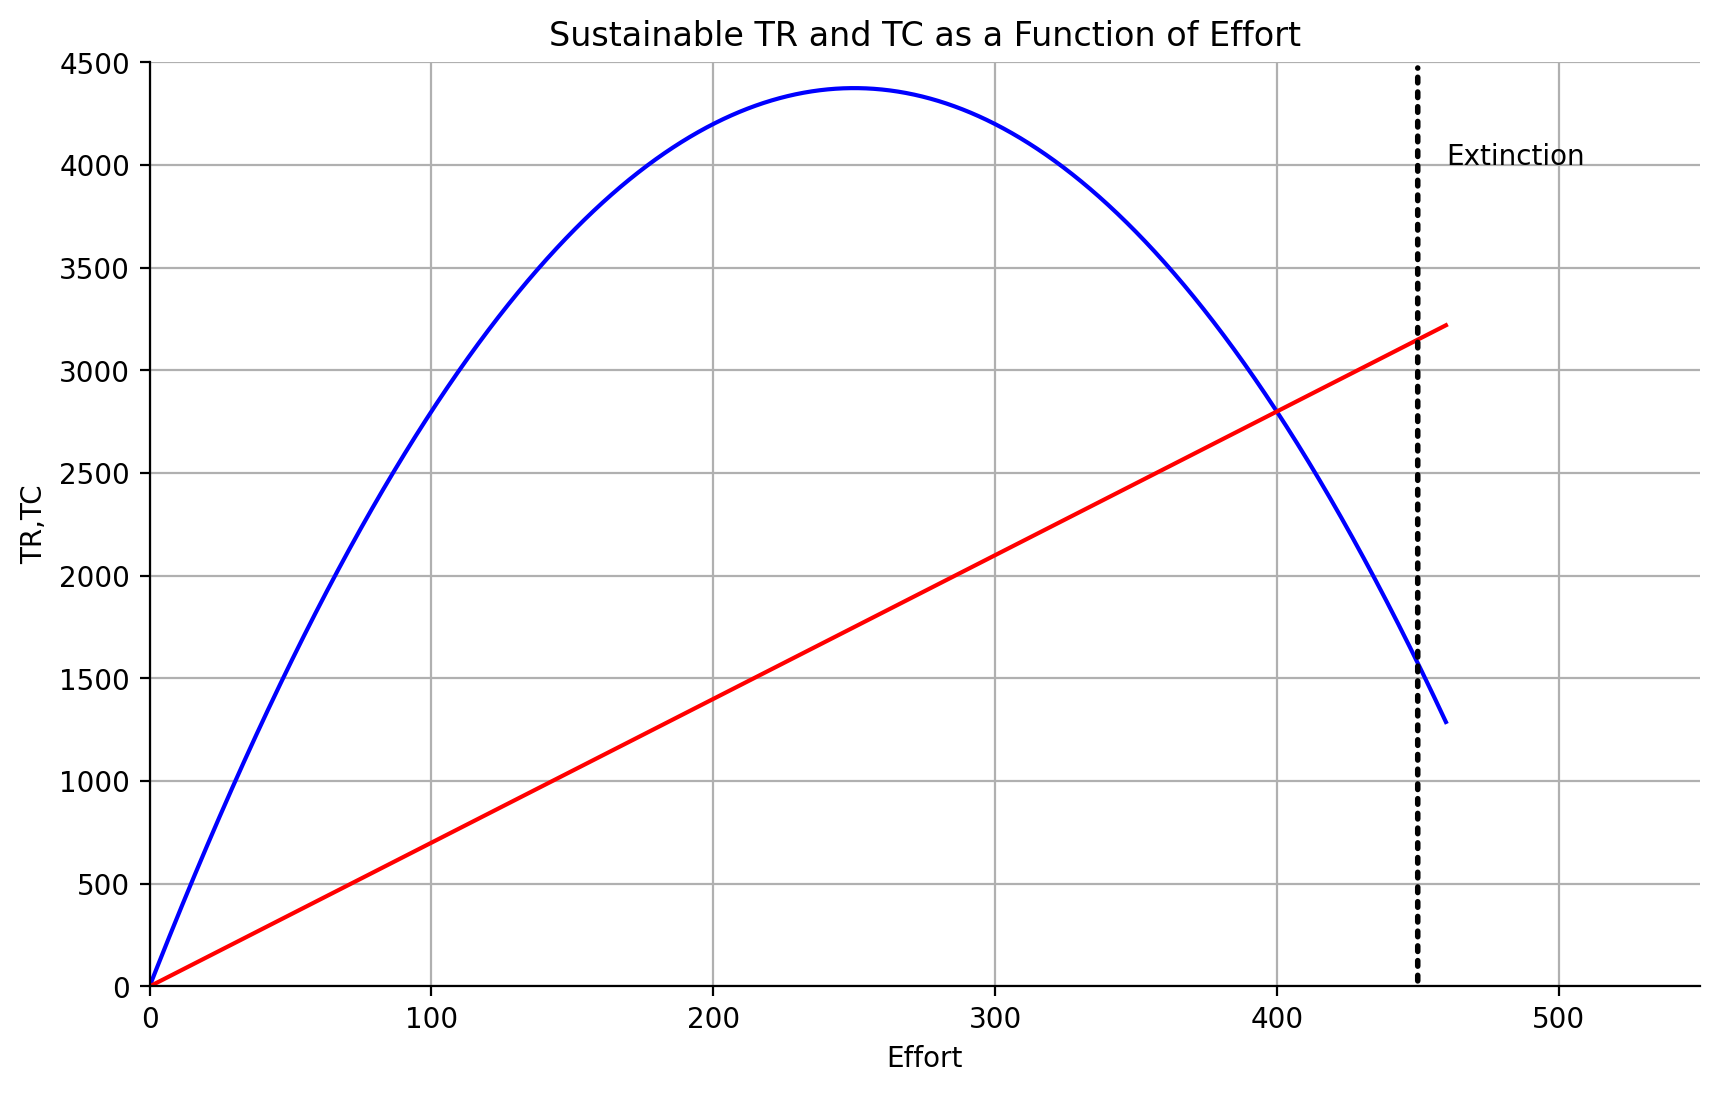

In [11]:
mask = (effort_ss >= 0) & (effort_ss <= 460)
plt.figure(figsize=(10, 6))
ax1 = plt.subplot(111)
plt.plot(effort_ss[mask], TR_ss[mask], c="b")
plt.plot(effort_ss[mask], TC[mask], c='r')
plt.xlabel("Effort")
plt.ylabel("TR,TC")
plt.title("Sustainable TR and TC as a Function of Effort")

plt.xlim(0,550)
plt.ylim(0,4500)
sbn.despine()
plt.grid()

plt.annotate("Extinction", xy=(460, 4000)
             )

plt.annotate(
    "",
    xy=(450, 4500),    # end point of the arrow (top of the line)
    xytext=(450,0),  # start point of the arrow (bottom of the line)
    arrowprops=dict(
        arrowstyle="-",
        linestyle="dotted",  # Set the line style to dotted
        color='black',
        linewidth=2
    )
   #  stock representation



    )

## 5. Steady State Dynamics


**Execute the following code and answer the question below.**

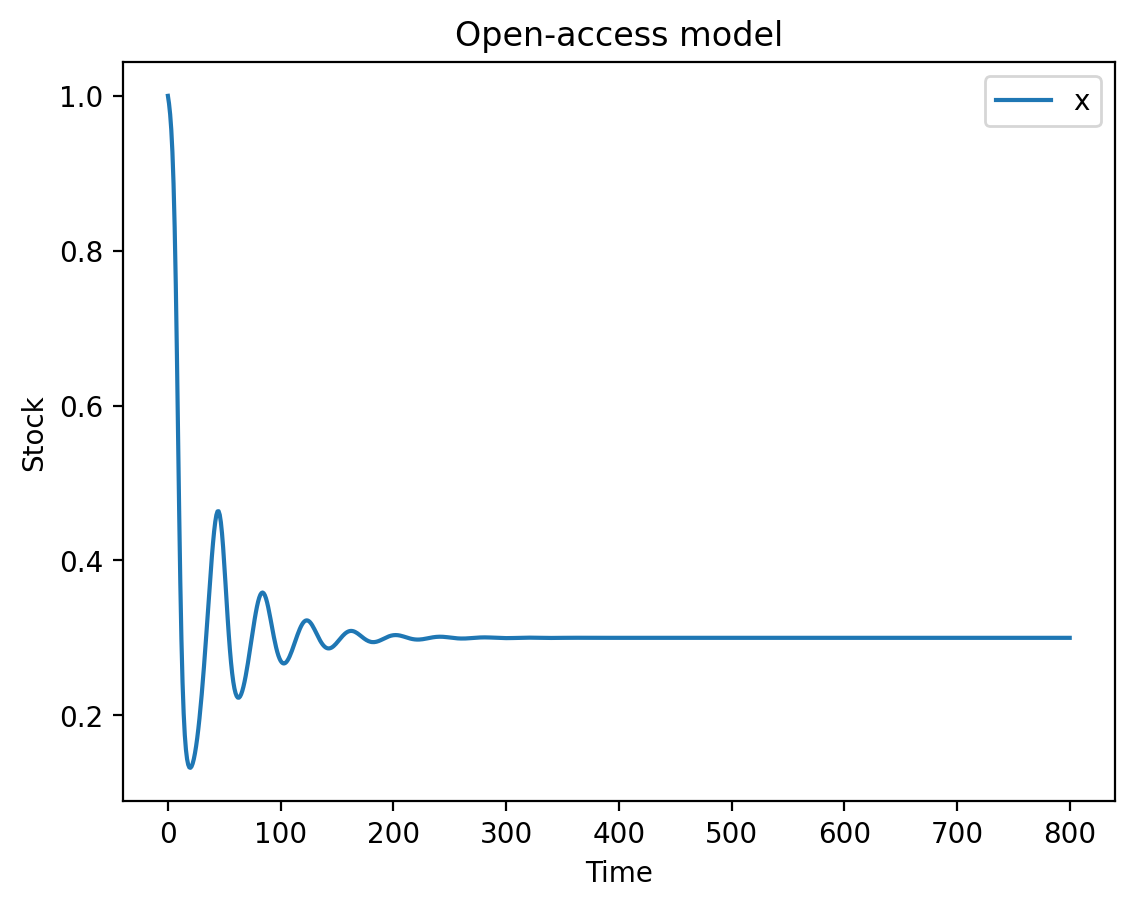

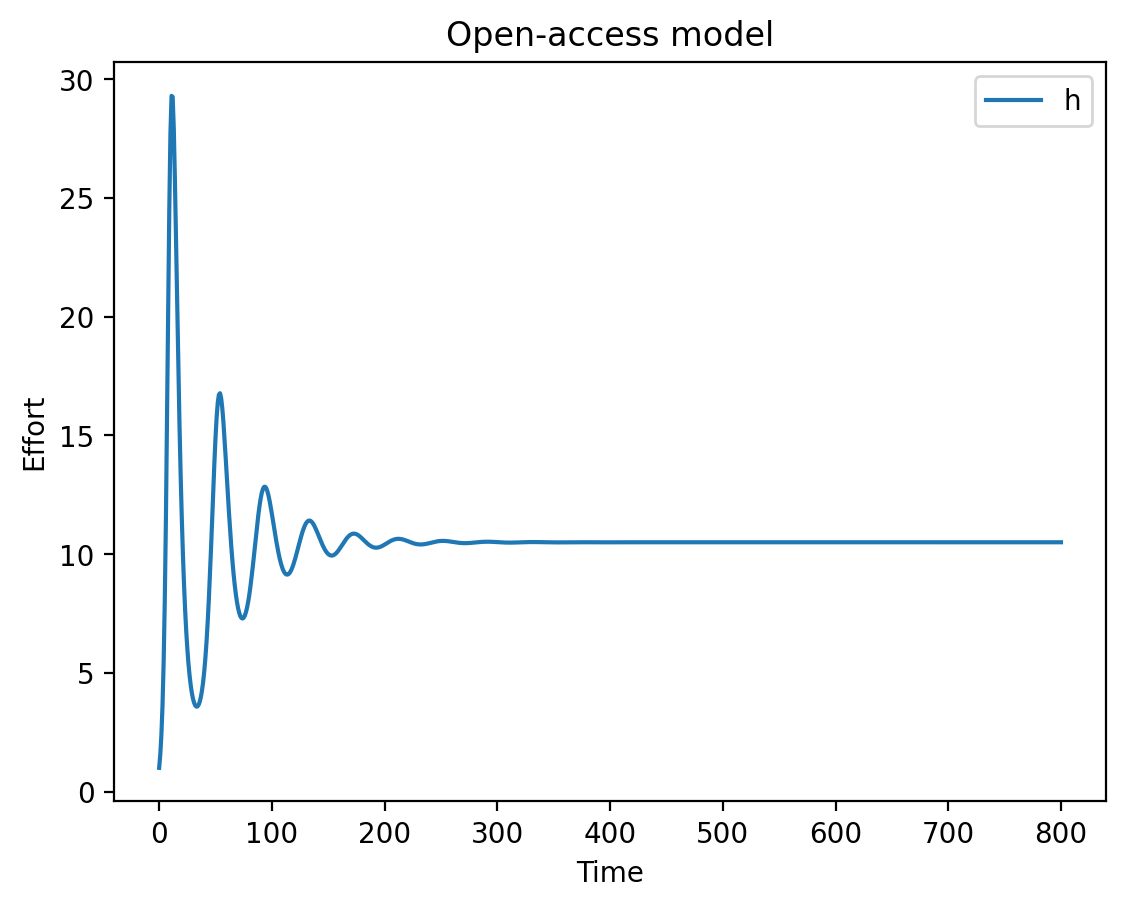

Steady State h 10.500000123386277
Steady State x 0.3000000027669364


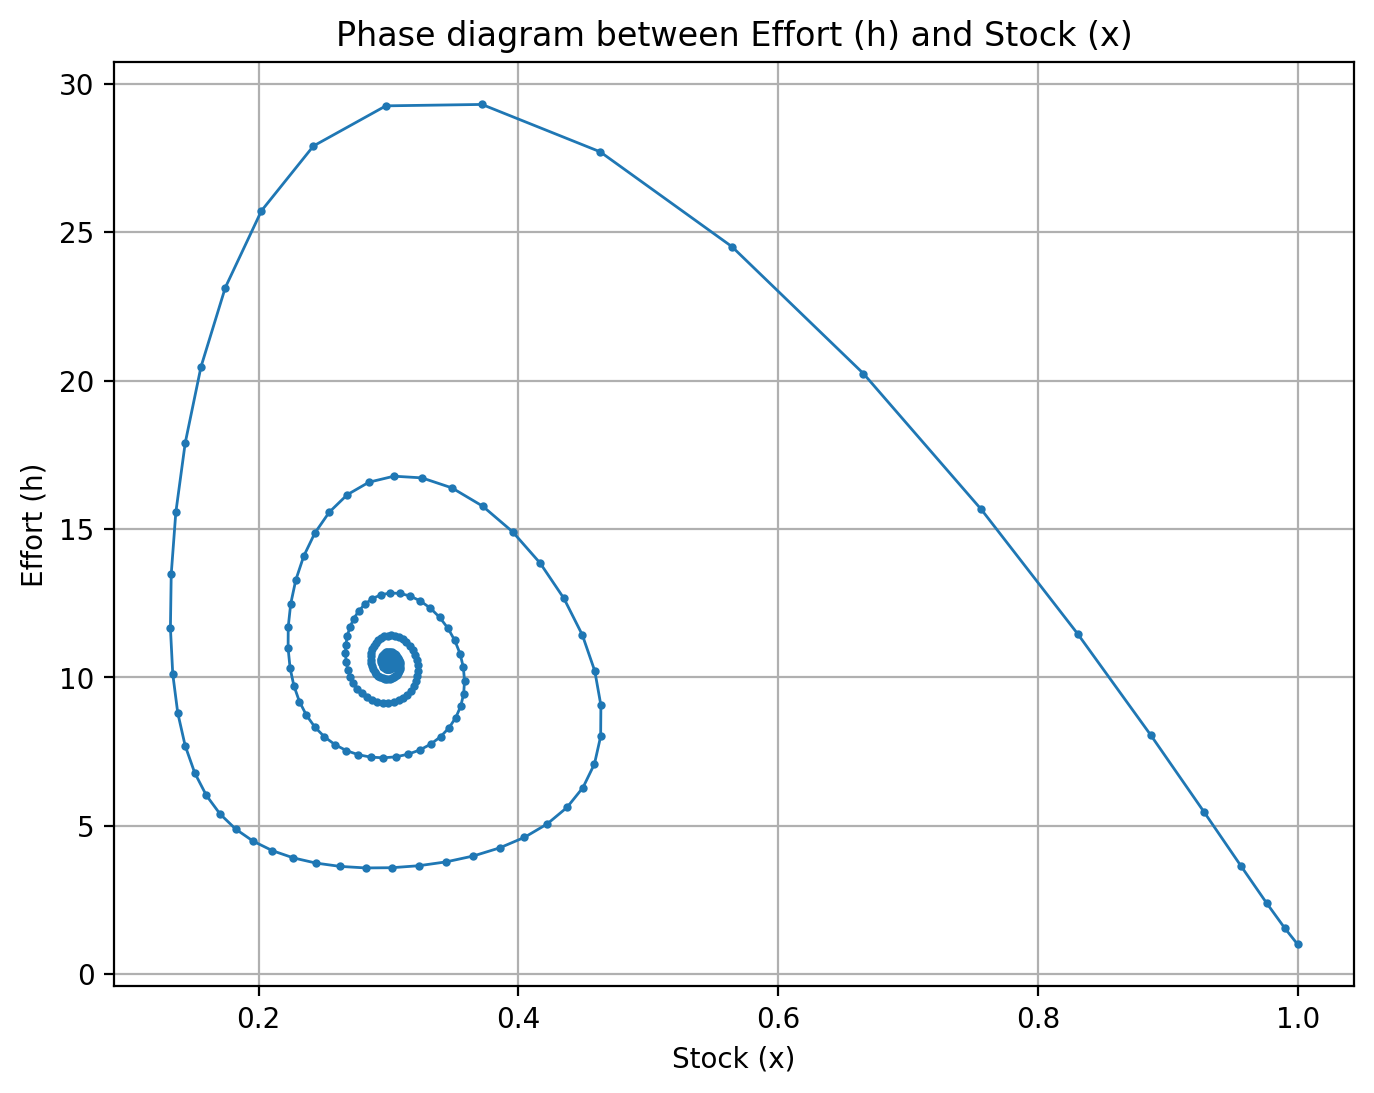

In [12]:
def open_access(gamma:float, x0:float, k_max: float, t0:float, T:float, h0:float, theta:float, d:float, p:float, w:float):
    stock = []
    effort = []
    timesteps = []
    x = x0
    h = h0
    t = t0
    stock.append(x)
    effort.append(h)
    timesteps.append(t)
    while t < T:
        q = theta*h*x #harvest function
        x = (x + gamma*x*(1-x/k_max)-q) #logistic regeneration function
        h = (h + d*(p*theta*h*x-w*h)) #open-access entry rule
        stock.append(x)
        effort.append(h)
        t = t + 1
        timesteps.append(t)
    return timesteps, stock, effort
    # simulate
#t, x, h = open_access(gamma = 0.15, x0=1, k_max= 1, t0= 0, T=800, h0=1, theta=0.01, w=0.6, d=0.4, p=200)
t, x, h = open_access(gamma = 0.15, x0=1, k_max= 1, t0= 0, T=800, h0=1, theta=0.01, w=0.6, d=0.4, p=200)
#plot stocks
plt.plot(t, x, label='x')
plt.xlabel("Time")
plt.ylabel("Stock")
plt.title("Open-access model")
plt.legend()
plt.show()

#plot effort
plt.plot(t, h, label='h')
plt.xlabel("Time")
plt.ylabel("Effort")
plt.title("Open-access model")
plt.legend()
plt.show()

#Show the last value for e and s in the list (rounded)
print("Steady State h",h[-1])
print("Steady State x",x[-1])

plt.figure(figsize=(8, 6))
plt.plot(x, h, '-o', markersize=2, linewidth=1)
plt.title('Phase diagram between Effort (h) and Stock (x)')
plt.xlabel('Stock (x)')
plt.ylabel('Effort (h)')
plt.grid(True)
plt.show()


---

**Question 9:** We can simulate the out of equilibrium dynamics of the model (i.e. the approach to equilibrium). Generate 2 diagrams with the following calibration where the price differs.

Case 1: g = 0.15, s0=1, s_max= 1, t0= 0, T=800, e0=1, a=0.01, w=0.6, d=0.4, p=200

Case 2: g = 0.15, s0=1, s_max= 1, t0= 0, T=800, e0=1, a=0.01, w=0.6, d=0.4, p=70

1.   Explain the dynamics of our two key variables, effort and stocks for both cases.
2.   What are the implications of this cyclical behaviour for policy on endagered animals. Can we do anything about it?
3.   In this model hunters are only concerned with immediate profits. How would the results of the model change if they were forward-looking.

---